# Naive Bayes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/naive_bayes.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 Bayes Theorem — the foundation
   - 2.2 The Naive Independence Assumption
   - 2.3 Full Derivation — from Bayes to classifier
   - 2.4 The Log-Sum Trick — avoiding underflow
   - 2.5 Gaussian Naive Bayes
   - 2.6 Multinomial Naive Bayes
   - 2.7 Bernoulli Naive Bayes
   - 2.8 Laplace Smoothing
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Common Mistakes](#6-common-mistakes)
7. [Exercises](#7-exercises)


## 1. Concept Overview

Naive Bayes is a probabilistic classifier based on **Bayes theorem** with the naive assumption that all features are **conditionally independent** given the class label. Despite this strong (and usually wrong) assumption, it works surprisingly well in practice — especially for text classification.

**When to use it:**
- Text classification (spam detection, sentiment analysis, document categorization)
- When training data is small — NB needs very few examples to estimate parameters
- Real-time prediction — extremely fast to train and predict
- As a strong baseline before trying complex models

**Strengths:** Fast, works on small data, handles high-dimensional data, no feature scaling needed, naturally probabilistic, good with irrelevant features (they average out)

**Weaknesses:** Independence assumption almost never true, poor probability calibration, cannot capture feature interactions, continuous features require distribution assumption


## 2. Math Intuition

### 2.1 Bayes Theorem — the Foundation

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y) \cdot P(y)}{P(\mathbf{x})}$$

- $P(y \mid \mathbf{x})$ — **posterior**: probability of class $y$ given features $\mathbf{x}$
- $P(\mathbf{x} \mid y)$ — **likelihood**: probability of observing $\mathbf{x}$ given class $y$
- $P(y)$ — **prior**: probability of class $y$ before observing any features
- $P(\mathbf{x})$ — **evidence**: same for all classes, acts as normalizer

For classification we want $\arg\max_y P(y \mid \mathbf{x})$, so we ignore $P(\mathbf{x})$:

$$\hat{y} = \arg\max_y\ P(\mathbf{x} \mid y) \cdot P(y)$$

---

### 2.2 The Naive Independence Assumption

The likelihood $P(\mathbf{x} \mid y)$ requires estimating a joint distribution over all $d$ features — exponentially complex without any independence assumption.

**Naive Bayes assumes all features are conditionally independent given $y$:**

$$P(x_1, x_2, \dots, x_d \mid y) = \prod_{j=1}^{d} P(x_j \mid y)$$

This reduces the problem to estimating $d$ independent univariate distributions. Even though this assumption is almost never true, NB often works because it only needs the **ranking** of posteriors to be correct, not their exact values.

---

### 2.3 Full Derivation — from Bayes to Classifier

Substituting the independence assumption:

$$\hat{y} = \arg\max_y\ P(y) \prod_{j=1}^{d} P(x_j \mid y)$$

**Estimating the prior:**

$$\hat{P}(y = c) = \frac{\text{samples with class } c}{m}$$

**Estimating the likelihood** depends on feature type — see sections 2.5–2.7.

---

### 2.4 The Log-Sum Trick — Avoiding Underflow

With many features, $\prod_{j=1}^{d} P(x_j \mid y)$ multiplies many small probabilities. With $d=1000$ features each with probability $0.01$, the product is $10^{-2000}$ — numerical underflow!

**Solution:** work in log space:

$$\hat{y} = \arg\max_y \left[ \log P(y) + \sum_{j=1}^{d} \log P(x_j \mid y) \right]$$

Log turns products into sums — no underflow possible.

---

### 2.5 Gaussian Naive Bayes

For **continuous features**, assume each feature $x_j$ follows a Gaussian distribution given class $c$:

$$P(x_j \mid y = c) = \frac{1}{\sqrt{2\pi \sigma_{jc}^2}} \exp\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

Parameters estimated from training data:

$$\hat{\mu}_{jc} = \frac{1}{m_c} \sum_{i: y_i = c} x_{ij} \qquad \hat{\sigma}_{jc}^2 = \frac{1}{m_c} \sum_{i: y_i = c} (x_{ij} - \hat{\mu}_{jc})^2$$

Log-likelihood:

$$\log P(x_j \mid y=c) = -\frac{1}{2}\log(2\pi\sigma_{jc}^2) - \frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}$$

---

### 2.6 Multinomial Naive Bayes

For **count features** (word counts), estimate probability of each feature per class:

$$\hat{\theta}_{jc} = \frac{N_{jc} + \alpha}{\sum_{k} N_{kc} + \alpha d}$$

where $N_{jc}$ is the count of feature $j$ in class $c$ samples and $\alpha$ is Laplace smoothing.

Prediction: $\hat{y} = \arg\max_c \left[\log P(y=c) + \sum_j x_j \log \theta_{jc}\right]$

---

### 2.7 Bernoulli Naive Bayes

For **binary features** (word present/absent):

$$P(x_j \mid y = c) = \theta_{jc}^{x_j} (1 - \theta_{jc})^{1 - x_j}$$

Key difference from Multinomial: **explicitly models the absence** of features. If word 'free' is absent, that is evidence the email is NOT spam.

---

### 2.8 Laplace Smoothing

**Problem:** If a feature was never seen with class $c$ in training, $P(x_j \mid y=c) = 0$, making the entire product zero regardless of all other features.

**Solution:** Add pseudocount $\alpha$ to every count:

$$\hat{P}(x_j = v \mid y = c) = \frac{N_{jcv} + \alpha}{\sum_{v'} N_{jcv'} + \alpha \cdot |\mathcal{V}_j|}$$

For $\alpha = 1$: **Laplace smoothing** (add-one smoothing). For $\alpha < 1$: **Lidstone smoothing** — less aggressive.


## 3. Visual Intuition

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


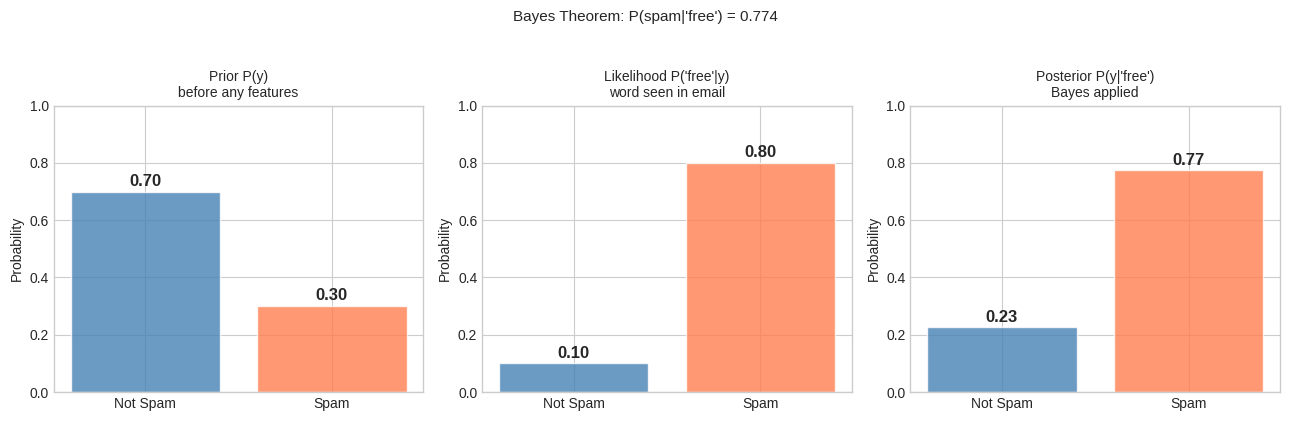

In [27]:
# ── Plot 1: Bayes theorem — visual prior -> likelihood -> posterior updating
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

prior_spam, prior_ham = 0.3, 0.7
p_free_spam, p_free_ham = 0.8, 0.1

unnorm_spam = p_free_spam * prior_spam
unnorm_ham  = p_free_ham  * prior_ham
evidence    = unnorm_spam + unnorm_ham
post_spam   = unnorm_spam / evidence
post_ham    = unnorm_ham  / evidence

categories = ['Not Spam', 'Spam']
colors     = ['steelblue', 'coral']

for ax, vals, title in zip(axes,
        [[prior_ham, prior_spam],
         [p_free_ham, p_free_spam],
         [post_ham, post_spam]],
        ["Prior P(y)\nbefore any features",
         "Likelihood P('free'|y)\nword seen in email",
         f"Posterior P(y|'free')\nBayes applied"]):
    bars = ax.bar(categories, vals, color=colors, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Probability'); ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle(f"Bayes Theorem: P(spam|'free') = {post_spam:.3f}", fontsize=11, y=1.04)
plt.tight_layout()
plt.show()


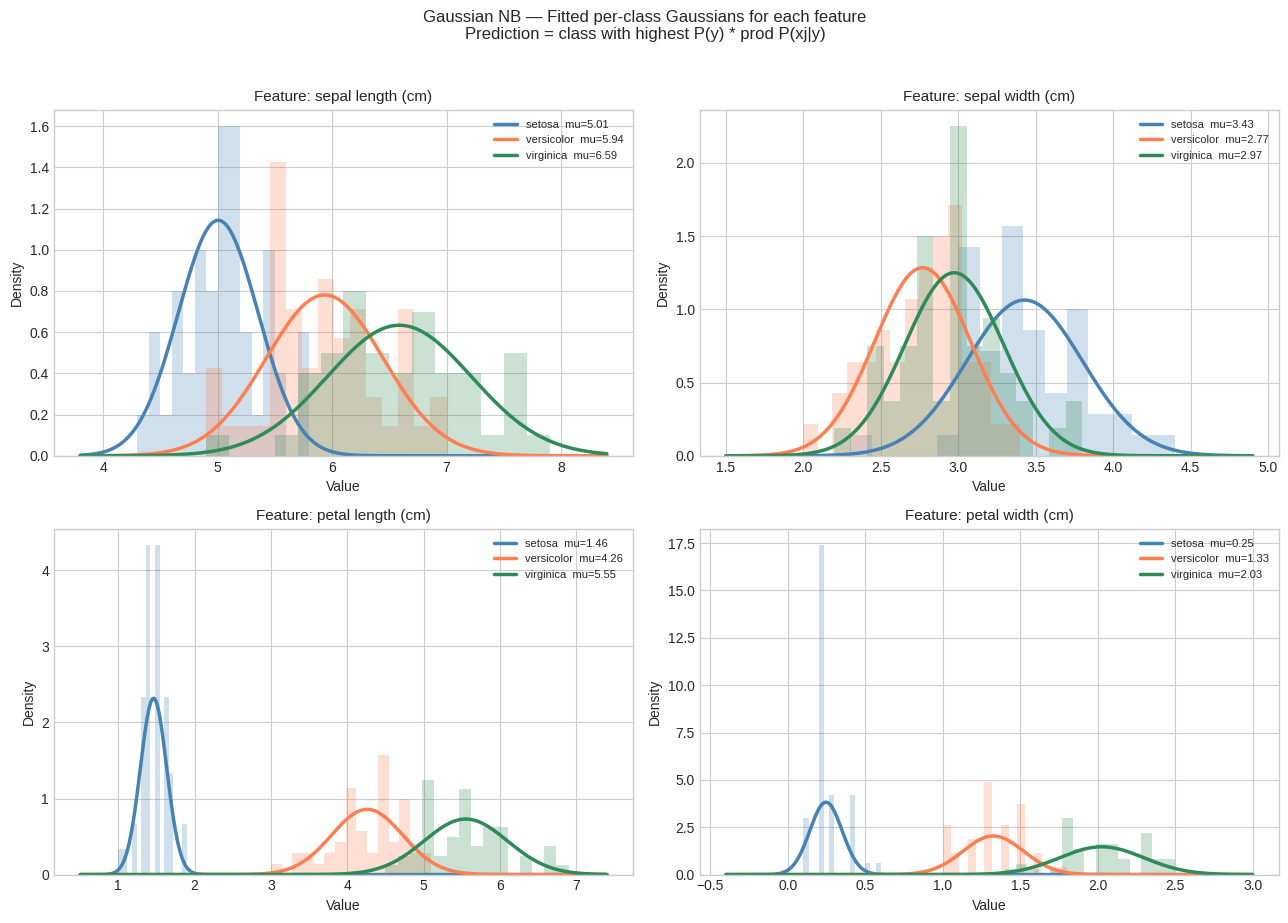

In [28]:
# ── Plot 2: Gaussian NB — per-class Gaussian distributions per feature
from sklearn.datasets import load_iris

iris = load_iris()
X_ir, y_ir = iris.data, iris.target
colors = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for feat_idx, ax in enumerate(axes):
    x_range = np.linspace(X_ir[:, feat_idx].min() - 0.5,
                          X_ir[:, feat_idx].max() + 0.5, 300)
    for cls, color, name in zip([0, 1, 2], colors, iris.target_names):
        x_cls = X_ir[y_ir == cls, feat_idx]
        mu, sigma = x_cls.mean(), x_cls.std()
        ax.hist(x_cls, bins=15, density=True, alpha=0.25, color=color)
        ax.plot(x_range, norm.pdf(x_range, mu, sigma), color=color,
                linewidth=2.5, label=f'{name}  mu={mu:.2f}')
    ax.set_title(f'Feature: {iris.feature_names[feat_idx]}', fontsize=11)
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Gaussian NB — Fitted per-class Gaussians for each feature\n'
             'Prediction = class with highest P(y) * prod P(xj|y)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


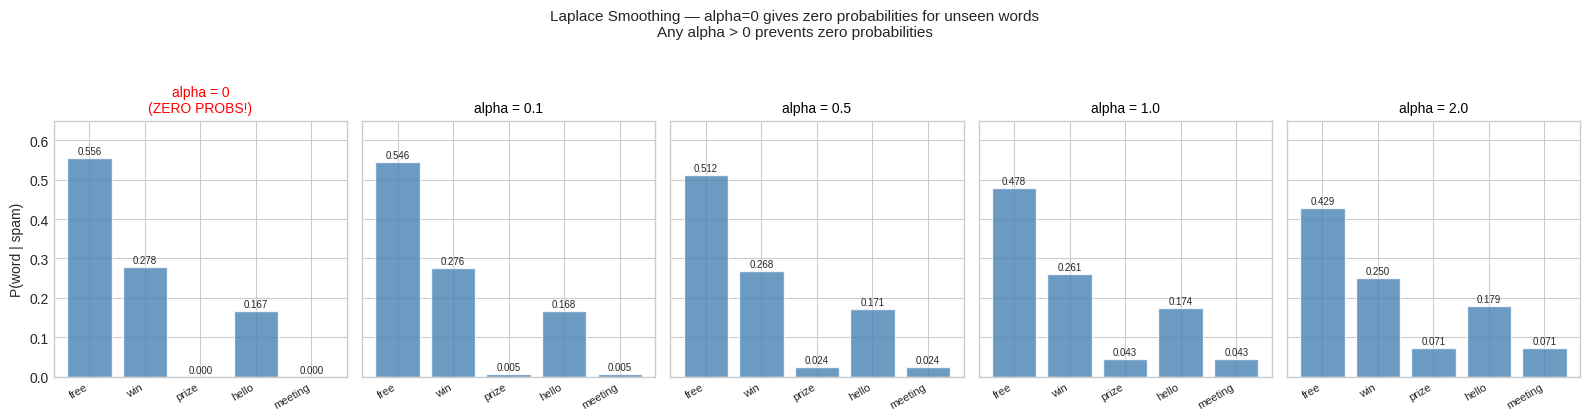

In [29]:
# ── Plot 3: Laplace smoothing — effect on probability estimates
vocab  = ['free', 'win', 'prize', 'hello', 'meeting']
counts = np.array([10, 5, 0, 3, 0], dtype=float)
total  = counts.sum()
alphas = [0, 0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax, alpha in zip(axes, alphas):
    probs = (counts + alpha) / (total + alpha * len(vocab))
    bars  = ax.bar(vocab, probs, color='steelblue', alpha=0.8, edgecolor='white')
    title = f'alpha = {alpha}' if alpha > 0 else 'alpha = 0\n(ZERO PROBS!)'
    color = 'black' if alpha > 0 else 'red'
    ax.set_title(title, fontsize=10, color=color)
    ax.set_xticklabels(vocab, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 0.65)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{p:.3f}', ha='center', fontsize=7)

axes[0].set_ylabel('P(word | spam)')
plt.suptitle('Laplace Smoothing — alpha=0 gives zero probabilities for unseen words\n'
             'Any alpha > 0 prevents zero probabilities', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()


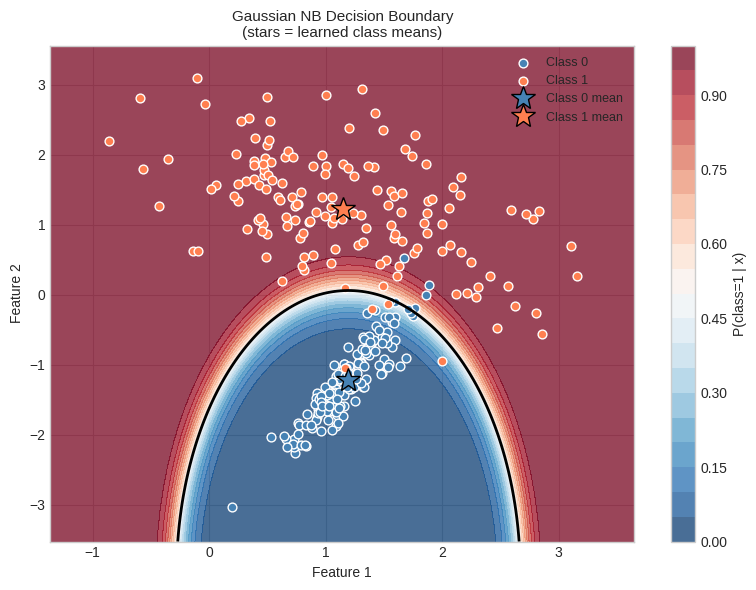

In [30]:
# ── Plot 4: Decision boundary of Gaussian NB
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification

X_nb, y_nb = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=42,
                                   n_clusters_per_class=1, class_sep=1.2)
gnb = GaussianNB().fit(X_nb, y_nb)

h = 0.03
x_min, x_max = X_nb[:,0].min()-0.5, X_nb[:,0].max()+0.5
y_min, y_max = X_nb[:,1].min()-0.5, X_nb[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = gnb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.75)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.colorbar(cf, ax=ax, label='P(class=1 | x)')
ax.scatter(X_nb[y_nb==0,0], X_nb[y_nb==0,1], c='steelblue',
           edgecolors='white', s=40, label='Class 0')
ax.scatter(X_nb[y_nb==1,0], X_nb[y_nb==1,1], c='coral',
           edgecolors='white', s=40, label='Class 1')
for cls, color in [(0,'steelblue'),(1,'coral')]:
    ax.plot(gnb.theta_[cls,0], gnb.theta_[cls,1], '*', color=color,
            markersize=18, markeredgecolor='black', markeredgewidth=1,
            zorder=6, label=f'Class {cls} mean')
ax.set_title('Gaussian NB Decision Boundary\n(stars = learned class means)', fontsize=11)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2'); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. Code from Scratch

In [31]:
class GaussianNBScratch:
    # Gaussian Naive Bayes from scratch.
    # For each class c and feature j:
    #   Estimate mu_jc, sigma_jc from training data.
    #   P(xj|y=c) = Normal(xj; mu_jc, sigma_jc^2)
    # Prediction: y_hat = argmax_c [log P(y=c) + sum_j log P(xj|y=c)]

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = self.log_priors_ = self.mu_ = self.sigma2_ = None

    def fit(self, X, y):
        m, d = X.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        self.log_priors_ = np.zeros(K)
        self.mu_         = np.zeros((K, d))
        self.sigma2_     = np.zeros((K, d))
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.log_priors_[idx] = np.log(len(X_c) / m)
            self.mu_[idx]         = X_c.mean(axis=0)
            self.sigma2_[idx]     = X_c.var(axis=0) + self.var_smoothing
        return self

    def _log_likelihood(self, X):
        # log N(x; mu, sigma^2) summed across features for each class
        # Returns shape (n_samples, n_classes)
        K = len(self.classes_)
        log_liks = np.zeros((X.shape[0], K))
        for idx in range(K):
            mu, s2 = self.mu_[idx], self.sigma2_[idx]
            log_liks[:, idx] = (
                -0.5 * np.sum(np.log(2 * np.pi * s2))
                - 0.5 * np.sum((X - mu)**2 / s2, axis=1)
            )
        return log_liks

    def predict_log_proba(self, X):
        return self._log_likelihood(X) + self.log_priors_

    def predict_proba(self, X):
        lp = self.predict_log_proba(X)
        lp -= lp.max(axis=1, keepdims=True)
        p   = np.exp(lp)
        return p / p.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


In [32]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X_ir, y_ir = iris.data, iris.target
X_tr, X_te, y_tr, y_te = train_test_split(X_ir, y_ir, test_size=0.2,
                                            random_state=42, stratify=y_ir)

gnb_sc = GaussianNBScratch()
gnb_sc.fit(X_tr, y_tr)

print('Gaussian NB from Scratch:')
print(f'  Train: {gnb_sc.score(X_tr, y_tr):.4f}  |  Test: {gnb_sc.score(X_te, y_te):.4f}')
print(f'\nLearned means:\n{gnb_sc.mu_.round(3)}')
print(f'Priors: {np.exp(gnb_sc.log_priors_).round(4)}')


Gaussian NB from Scratch:
  Train: 0.9583  |  Test: 0.9667

Learned means:
[[4.985 3.415 1.477 0.255]
 [5.93  2.75  4.252 1.32 ]
 [6.61  2.98  5.58  2.04 ]]
Priors: [0.3333 0.3333 0.3333]


In [33]:
from sklearn.naive_bayes import GaussianNB

gnb_sk = GaussianNB()
gnb_sk.fit(X_tr, y_tr)
print(f'Sklearn GaussianNB test accuracy: {gnb_sk.score(X_te, y_te):.4f}')
print('Results should match exactly.')


Sklearn GaussianNB test accuracy: 0.9667
Results should match exactly.


In [34]:
class MultinomialNBScratch:
    # Multinomial Naive Bayes for count features (e.g. word counts).
    # theta_jc = (N_jc + alpha) / (sum_k N_kc + alpha * d)
    # Prediction: y_hat = argmax_c [log P(y=c) + sum_j x_j * log(theta_jc)]

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = self.log_priors_ = self.log_theta_ = None

    def fit(self, X, y):
        m, d = X.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        self.log_priors_ = np.zeros(K)
        self.log_theta_  = np.zeros((K, d))
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.log_priors_[idx] = np.log(len(X_c) / m)
            feat_counts = X_c.sum(axis=0) + self.alpha
            self.log_theta_[idx]  = np.log(feat_counts / feat_counts.sum())
        return self

    def predict_log_proba(self, X):
        return X @ self.log_theta_.T + self.log_priors_

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


In [35]:
rng4 = np.random.default_rng(7)
X_spam = rng4.integers(0, 10, (150, 6))
X_spam[:, 3:] = rng4.integers(0, 2, (150, 3))
X_ham  = rng4.integers(0, 2, (150, 6))
X_ham[:, 3:]  = rng4.integers(0, 10, (150, 3))
X_txt = np.vstack([X_spam, X_ham]).astype(float)
y_txt = np.array([1]*150 + [0]*150)
idx = rng4.permutation(300)
X_txt, y_txt = X_txt[idx], y_txt[idx]

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_txt, y_txt,
                                                     test_size=0.2, random_state=42)
mnb = MultinomialNBScratch(alpha=1.0)
mnb.fit(X_tr_t, y_tr_t)
print(f'Multinomial NB Scratch — Train: {mnb.score(X_tr_t, y_tr_t):.4f}  Test: {mnb.score(X_te_t, y_te_t):.4f}')


Multinomial NB Scratch — Train: 0.9958  Test: 1.0000


## 5. Sklearn Implementation

In [36]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.datasets import fetch_20newsgroups
import warnings; warnings.filterwarnings('ignore')

gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_tr, y_tr)
print(f'GaussianNB Iris test accuracy: {gnb.score(X_te, y_te):.4f}')
print(f'Classes:  {gnb.classes_}')
print(f'Priors:   {gnb.class_prior_.round(4)}')
print(f'Means:\n{gnb.theta_.round(3)}')


GaussianNB Iris test accuracy: 0.9667
Classes:  [0 1 2]
Priors:   [0.3333 0.3333 0.3333]
Means:
[[4.985 3.415 1.477 0.255]
 [5.93  2.75  4.252 1.32 ]
 [6.61  2.98  5.58  2.04 ]]


In [37]:
# Text classification — 4 newsgroups
categories = ['rec.sport.hockey', 'sci.space', 'talk.politics.guns', 'comp.graphics']
train_data = fetch_20newsgroups(subset='train', categories=categories,
                                 remove=('headers','footers','quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                 remove=('headers','footers','quotes'))

text_pipe = Pipeline([
    ('vect',  CountVectorizer(max_features=10000, stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('clf',   MultinomialNB(alpha=0.1))
])
text_pipe.fit(train_data.data, train_data.target)

from sklearn.metrics import classification_report
y_pred_text = text_pipe.predict(test_data.data)
print(f'MultinomialNB — 20 Newsgroups test accuracy: {text_pipe.score(test_data.data, test_data.target):.4f}')
print()
print(classification_report(test_data.target, y_pred_text, target_names=test_data.target_names))


MultinomialNB — 20 Newsgroups test accuracy: 0.9075

                    precision    recall  f1-score   support

     comp.graphics       0.93      0.92      0.93       389
  rec.sport.hockey       0.89      0.95      0.92       399
         sci.space       0.92      0.85      0.88       394
talk.politics.guns       0.90      0.91      0.90       364

          accuracy                           0.91      1546
         macro avg       0.91      0.91      0.91      1546
      weighted avg       0.91      0.91      0.91      1546



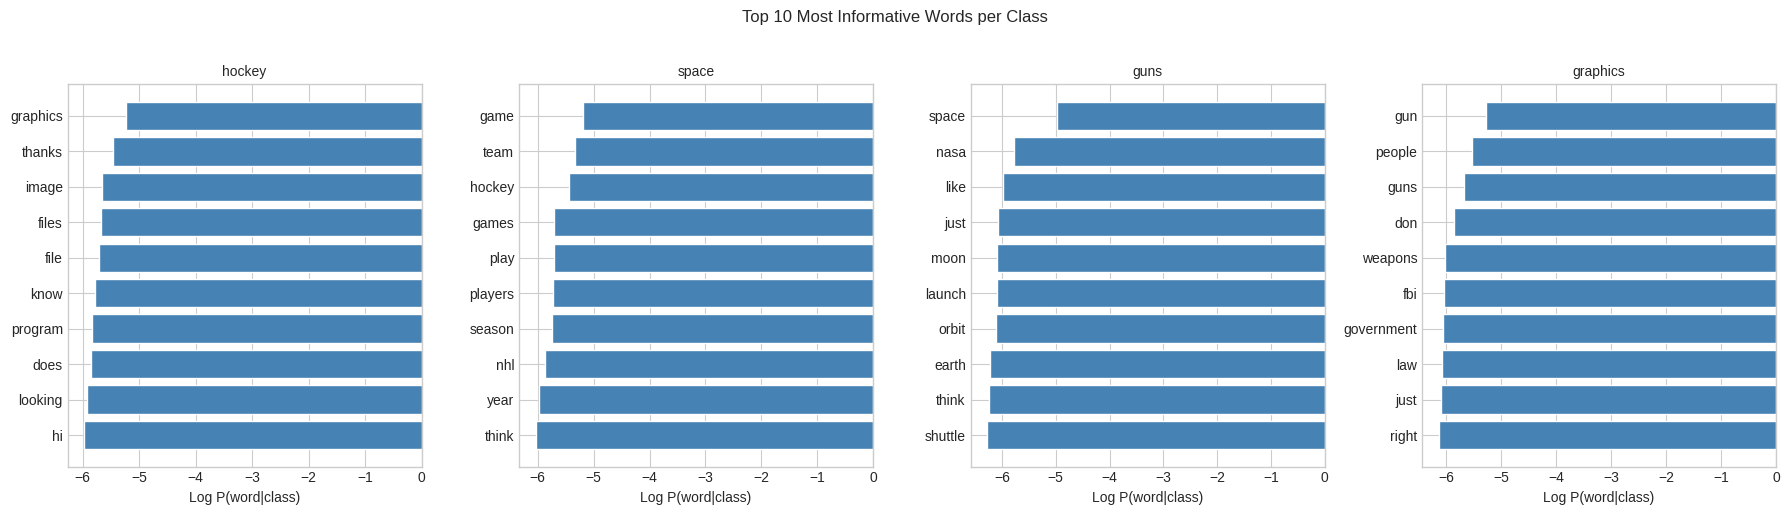

In [38]:
# Most informative features per class
vect       = text_pipe.named_steps['vect']
clf        = text_pipe.named_steps['clf']
feat_names = np.array(vect.get_feature_names_out())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for idx, (ax, cat) in enumerate(zip(axes, categories)):
    top10_idx   = clf.feature_log_prob_[idx].argsort()[-10:]
    ax.barh(feat_names[top10_idx], clf.feature_log_prob_[idx][top10_idx],
            color='steelblue', edgecolor='white')
    ax.set_title(cat.split('.')[-1], fontsize=10)
    ax.set_xlabel('Log P(word|class)')

plt.suptitle('Top 10 Most Informative Words per Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [39]:
# Compare NB variants
from sklearn.preprocessing import Binarizer
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

print('Comparing NB variants on Iris:')
print(f'{"Variant":<22}  {"CV Accuracy":>12}  {"Std":>8}')
for name, clf in [
    ('GaussianNB',   GaussianNB()),
    ('BernoulliNB',  Pipeline([('bin', Binarizer(threshold=0.0)), ('clf', BernoulliNB())])),
]:
    s = cross_val_score(clf, X_ir, y_ir, cv=5, scoring='accuracy')
    print(f'{name:<22}  {s.mean():12.4f}  {s.std():8.4f}')
print('\nGaussianNB is the right choice for continuous features.')


Comparing NB variants on Iris:
Variant                  CV Accuracy       Std
GaussianNB                    0.9533    0.0267
BernoulliNB                   0.3333    0.0000

GaussianNB is the right choice for continuous features.


## 6. Common Mistakes

In [40]:
# MISTAKE 1: Using MultinomialNB with negative features
# MultinomialNB requires non-negative features — it models count data.
# If features can be negative, use GaussianNB or ComplementNB.

print('MultinomialNB requires non-negative features (count data).')
print('For TF-IDF features, use ComplementNB (often outperforms MultinomialNB).')
print('For continuous features, use GaussianNB.')
print('For binary features (present/absent), use BernoulliNB.')

from sklearn.naive_bayes import ComplementNB
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# ComplementNB often better for imbalanced text classes
categories2 = ['rec.sport.hockey', 'sci.space']
d_tr = fetch_20newsgroups(subset='train', categories=categories2,
                           remove=('headers','footers','quotes'))
d_te = fetch_20newsgroups(subset='test',  categories=categories2,
                           remove=('headers','footers','quotes'))

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tr_txt = tfidf.fit_transform(d_tr.data)
X_te_txt = tfidf.transform(d_te.data)

print(f'{'Model':<20}  {"Test Acc":>10}')
for name, model in [('MultinomialNB', MultinomialNB()),
                     ('ComplementNB',  ComplementNB())]:
    model.fit(X_tr_txt, d_tr.target)
    print(f'{name:<20}  {model.score(X_te_txt, d_te.target):10.4f}')


MultinomialNB requires non-negative features (count data).
For TF-IDF features, use ComplementNB (often outperforms MultinomialNB).
For continuous features, use GaussianNB.
For binary features (present/absent), use BernoulliNB.
Model                   Test Acc
MultinomialNB             0.9521
ComplementNB              0.9521


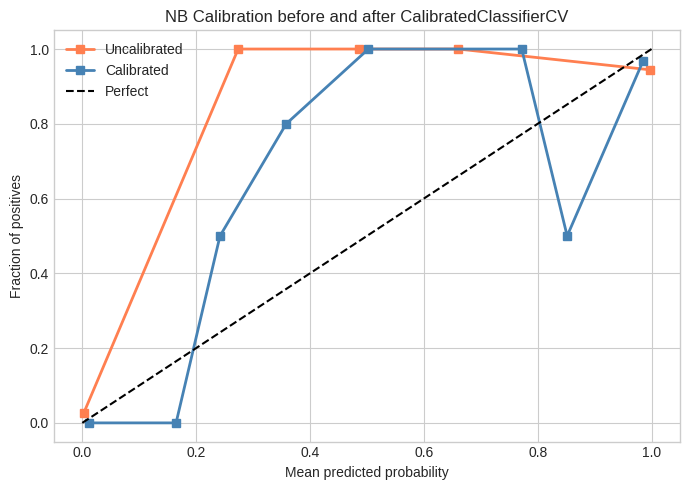

NB probabilities are overconfident. Use CalibratedClassifierCV for reliable probs.


In [41]:
# MISTAKE 2: Trusting NB probabilities as calibrated
# NB posteriors are often extreme (near 0 or 1) — independence assumption
# makes the model overconfident. Use CalibratedClassifierCV.

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

gnb_raw = GaussianNB()
gnb_cal = CalibratedClassifierCV(GaussianNB(), cv=5, method='isotonic')
gnb_raw.fit(X_tr_bc, y_tr_bc)
gnb_cal.fit(X_tr_bc, y_tr_bc)

p_raw = gnb_raw.predict_proba(X_te_bc)[:,1]
p_cal = gnb_cal.predict_proba(X_te_bc)[:,1]

fig, ax = plt.subplots(figsize=(7, 5))
for proba, label, color in [(p_raw,'Uncalibrated','coral'),(p_cal,'Calibrated','steelblue')]:
    pt, pp = calibration_curve(y_te_bc, proba, n_bins=10)
    ax.plot(pp, pt, 's-', color=color, linewidth=2, label=label)
ax.plot([0,1],[0,1],'k--',linewidth=1.5, label='Perfect')
ax.set_title('NB Calibration before and after CalibratedClassifierCV')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.legend()
plt.tight_layout()
plt.show()
print('NB probabilities are overconfident. Use CalibratedClassifierCV for reliable probs.')


In [42]:
# MISTAKE 3: Forgetting smoothing — zero probability kills the posterior
vocab   = ['free', 'win', 'prize', 'hello', 'meeting']
counts0 = np.array([10, 5, 2, 0, 0], dtype=float)
test_doc = np.array([0, 0, 0, 1, 0])   # 'hello' never seen in class 0

print('Effect of alpha on log-probability for a word never seen in training:')
for alpha in [0.0, 0.1, 1.0]:
    theta = (counts0 + alpha) / (counts0.sum() + alpha * len(vocab))
    # Avoid log(0) warning
    with np.errstate(divide='ignore'):
        log_p = np.sum(test_doc * np.log(np.where(theta > 0, theta, 1e-300)))
    print(f'  alpha={alpha}: theta={theta.round(4)}, log P(doc|class) = {log_p:.4f}')

print()
print('With alpha=0: log P = -inf. Always use alpha > 0.')


Effect of alpha on log-probability for a word never seen in training:
  alpha=0.0: theta=[0.5882 0.2941 0.1176 0.     0.    ], log P(doc|class) = -690.7755
  alpha=0.1: theta=[0.5771 0.2914 0.12   0.0057 0.0057], log P(doc|class) = -5.1648
  alpha=1.0: theta=[0.5    0.2727 0.1364 0.0455 0.0455], log P(doc|class) = -3.0910

With alpha=0: log P = -inf. Always use alpha > 0.


## 7. Exercises

**Exercise 1:** Apply Bayes theorem manually to a spam detection problem.

Given:
- $P(\text{spam}) = 0.4$
- $P(\text{free} \mid \text{spam}) = 0.7$, $P(\text{free} \mid \text{ham}) = 0.1$
- $P(\text{click} \mid \text{spam}) = 0.5$, $P(\text{click} \mid \text{ham}) = 0.05$

An email contains both 'free' and 'click'. Under the naive independence assumption, what is $P(\text{spam} \mid \text{free, click})$?


In [43]:
# Your code here


In [44]:
# Solution
p_spam, p_ham = 0.4, 0.6
p_free_spam, p_free_ham   = 0.7, 0.1
p_click_spam, p_click_ham = 0.5, 0.05

unnorm_spam = p_spam * p_free_spam * p_click_spam
unnorm_ham  = p_ham  * p_free_ham  * p_click_ham
evidence    = unnorm_spam + unnorm_ham

post_spam = unnorm_spam / evidence
post_ham  = unnorm_ham  / evidence

print('Applying Bayes theorem with independence assumption:')
print(f'  unnorm spam = {p_spam} * {p_free_spam} * {p_click_spam} = {unnorm_spam:.4f}')
print(f'  unnorm ham  = {p_ham} * {p_free_ham} * {p_click_ham} = {unnorm_ham:.4f}')
print(f'  evidence    = {evidence:.4f}')
print(f'  P(spam|free,click) = {post_spam:.4f}  ({post_spam*100:.1f}%)')
print(f'  Prediction: {"SPAM" if post_spam > 0.5 else "HAM"}')


Applying Bayes theorem with independence assumption:
  unnorm spam = 0.4 * 0.7 * 0.5 = 0.1400
  unnorm ham  = 0.6 * 0.1 * 0.05 = 0.0030
  evidence    = 0.1430
  P(spam|free,click) = 0.9790  (97.9%)
  Prediction: SPAM


**Exercise 2:** Implement `BernoulliNBScratch`. The key difference from MultinomialNB is that **absent features are explicitly modeled**:

$$\log P(\mathbf{x} \mid y=c) = \sum_{j} \left[ x_j \log \theta_{jc} + (1-x_j) \log(1-\theta_{jc}) \right]$$

Test it on a binarized version of the breast cancer dataset and compare with sklearn BernoulliNB.


In [45]:
# Your code here


In [46]:
# Solution
class BernoulliNBScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        m, d = X.shape
        self.classes_     = np.unique(y)
        K = len(self.classes_)
        self.log_priors_  = np.zeros(K)
        self.log_theta_   = np.zeros((K, d))
        self.log_1theta_  = np.zeros((K, d))
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            m_c = len(X_c)
            self.log_priors_[idx] = np.log(m_c / m)
            theta = (X_c.sum(axis=0) + self.alpha) / (m_c + 2 * self.alpha)
            self.log_theta_[idx]  = np.log(theta)
            self.log_1theta_[idx] = np.log(1 - theta)
        return self

    def predict(self, X):
        log_post = X @ self.log_theta_.T + (1-X) @ self.log_1theta_.T + self.log_priors_
        return self.classes_[log_post.argmax(axis=1)]

    def score(self, X, y): return np.mean(self.predict(X) == y)

from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import load_breast_cancer

data_bc = load_breast_cancer()
X_b, y_b = data_bc.data, data_bc.target
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_b, y_b, test_size=0.2,
                                                    random_state=42, stratify=y_b)

# Per-feature median thresholding (Binarizer supports only scalar threshold).
med = np.median(X_tr_b, axis=0)
X_bin_tr = (X_tr_b > med).astype(float)
X_bin_te = (X_te_b > med).astype(float)

bnb_sc = BernoulliNBScratch(alpha=1.0)
bnb_sk = BernoulliNB(alpha=1.0)
bnb_sc.fit(X_bin_tr, y_tr_b)
bnb_sk.fit(X_bin_tr, y_tr_b)
print(f'BernoulliNB Scratch: {bnb_sc.score(X_bin_te, y_te_b):.4f}')
print(f'BernoulliNB Sklearn: {bnb_sk.score(X_bin_te, y_te_b):.4f}')


BernoulliNB Scratch: 0.9123
BernoulliNB Sklearn: 0.9123


**Exercise 3:** Show that naive independence can still give correct **rankings** even when probabilities are wrong. Create a dataset with strongly correlated features, train GaussianNB and Logistic Regression, and compare accuracy vs Brier score (calibration error).


In [47]:
# Your code here


In [48]:
# Solution
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

rng5 = np.random.default_rng(0)
n = 500
x1 = rng5.normal(0, 1, n)
x2 = np.concatenate([x1[:n//2] + rng5.normal(0, 0.2, n//2),
                     x1[n//2:] + rng5.normal(2, 0.2, n//2)])
X_cor = np.column_stack([x1, x2])
y_cor = np.array([0]*(n//2) + [1]*(n//2))

print(f'Feature correlation: {np.corrcoef(X_cor.T)[0,1]:.4f} (strong!)')

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cor, y_cor, test_size=0.3, random_state=0)
gnb_c = GaussianNB().fit(X_tr_c, y_tr_c)
lr_c  = LogisticRegression().fit(X_tr_c, y_tr_c)

p_gnb = gnb_c.predict_proba(X_te_c)[:,1]
p_lr  = lr_c.predict_proba(X_te_c)[:,1]

print(f'{"Model":<22}  {"Accuracy":>10}  {"Brier Score":>12}')
print(f'{"GaussianNB":<22}  {gnb_c.score(X_te_c, y_te_c):10.4f}  {brier_score_loss(y_te_c, p_gnb):12.4f}')
print(f'{"Logistic Regression":<22}  {lr_c.score(X_te_c, y_te_c):10.4f}  {brier_score_loss(y_te_c, p_lr):12.4f}')
print()
print('Key insight: NB accuracy ~ LogReg accuracy, but Brier score is worse.')
print('NB gets the ranking right (correct predictions) even though')
print('its probability estimates are overconfident.')


Feature correlation: 0.7009 (strong!)
Model                     Accuracy   Brier Score
GaussianNB                  0.8733        0.0868
Logistic Regression         1.0000        0.0008

Key insight: NB accuracy ~ LogReg accuracy, but Brier score is worse.
NB gets the ranking right (correct predictions) even though
its probability estimates are overconfident.


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
